### Persistence

LangGraph includes a built-in persistence layer using checkpointers.

#### How Checkpointers Work
When a graph is compiled with a checkpointer, the checkpointer automatically saves a snapshot (checkpoint) of the graph state after every super-step (a complete cycle or step in the graph execution).

#### Capabilities Enabled
These checkpoints are saved to a thread that remains accessible after the graph execution finishes. Because the graph's state can be accessed post-execution, this persistence layer enables several powerful features:

   - Memory: Provides the graph with the ability to recall past states and interactions.

   - Human-in-the-Loop: Allows a human to inspect or intervene in the execution process.
    
   - Time Travel: Makes it possible to rewind the graph state to a previous point.
    
   - Fault-Tolerance: Enables the system to recover from failures by resuming execution from the last saved checkpoint.


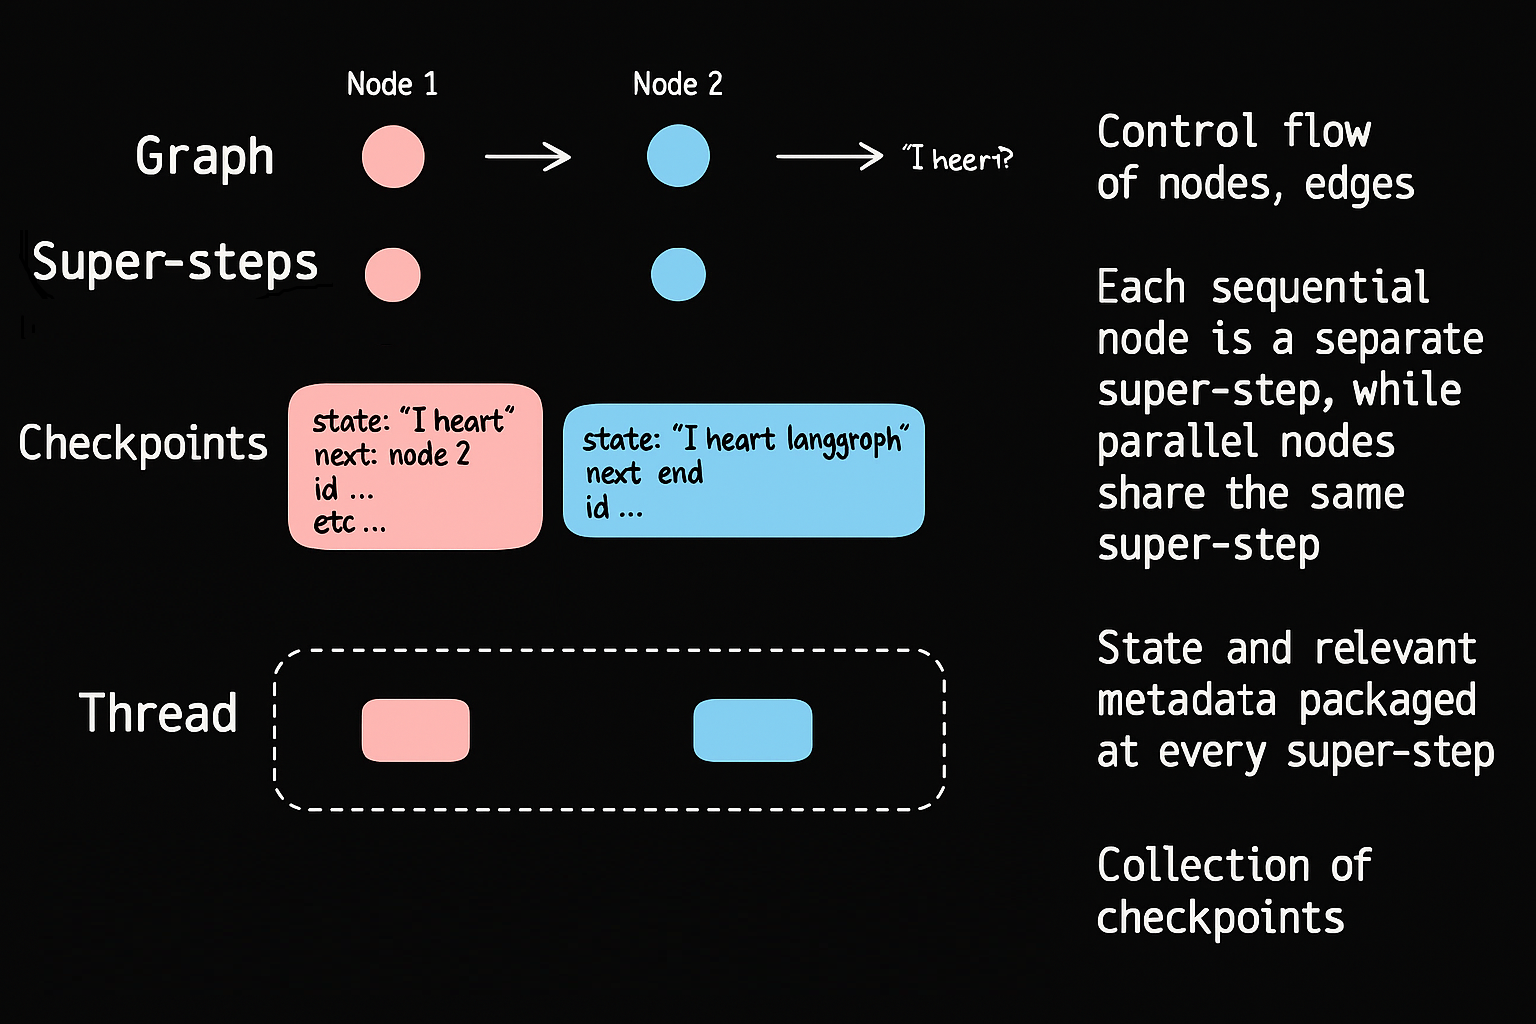

## Example 1 : Persistance with InMemorySaver

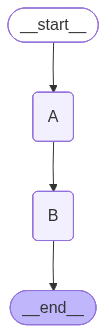

In [1]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
 
#  Define the state schema ---

#The total=False argument in the class definition is a feature that 
#allows the fields of the TypedDict to be optional.

class AgentState(TypedDict, total=False):
    a: Optional[str]  #Annotated[Optional[str],operator.add]
    b: Optional[str]
 
#  Define nodes ---
def node_a(state: AgentState) -> AgentState:
    state["a"] = "Hello"
    return state
 
def node_b(state: AgentState) -> AgentState:
    state["b"] = state["a"] + " World!"
    return state
 
# Build graph ---
builder = StateGraph(AgentState)
 
builder.add_node("A", node_a)
builder.add_node("B", node_b)
 
builder.set_entry_point("A")
builder.add_edge("A", "B")
 
#  Compile with a checkpoint saver ---
graph = builder.compile(checkpointer=InMemorySaver())
graph



In [2]:
config = {"configurable": {"thread_id": "thread_1"}}

final_state = graph.invoke({"a":"Hi"}, config=config)
print(final_state)

{'a': 'Hello', 'b': 'Hello World!'}


In [3]:
# Assuming you have a configured graph object `graph` and a configuration `config`
from rich import print
# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)

from rich import print
#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")


<generator object Pregel.get_state_history at 0x77aa0ce3b290>

State 1: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172f-615e-8002-0e3f1b83956e'}}, metadata={'source': 
'loop', 'step': 2, 'parents': {}}, created_at='2026-03-11T12:02:09.142399+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172c-6b82-8001-9023c4a5ea1b'}}, tasks=(),
interrupts=())

State 2: StateSnapshot(values={'a': 'Hello'}, next=('B',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172c-6b82-8001-9023c4a5ea1b'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-03-11T12:02:09.141430+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172a-6bb4-8000-7d058e04557e'}}, 
tasks=(PregelTask(id='af66e8de-7d7c-50a9-8afc-f2010fe7757e', name='B', path=('__pregel_pull', 'B'), error=None, 
interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), interrupts=())

State 3: StateSnapshot(values={'a': 'Hi'}, next=('A',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172a-6bb4-8000-7d058e04557e'}}, metadata={'source': 'loop', 'step':
0, 'parents': {}}, created_at='2026-03-11T12:02:09.140614+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-1728-6b21-bfff-0993cdd85bc6'}}, 
tasks=(PregelTask(id='b3da18dc-d911-d270-546c-ea44d9e6bcc1', name='A', path=('__pregel_pull', 'A'), error=None, 
interrupts=(), state=None, result={'a': 'Hello'}),), interrupts=())

State 4: StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d422-1728-6b21-bfff-0993cdd85bc6'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-03-11T12:02:09.139781+00:00', parent_config=None, 
tasks=(PregelTask(id='8d1f51de-6106-4d49-8621-07f86e60e903', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'a': 'Hi'}),), interrupts=())

In [6]:
config = {"configurable": {"thread_id": "thread_1"}}

final_state = graph.invoke({"a":"I am Raj"}, config=config)

print(final_state)

{'a': 'Hello', 'b': 'Hello World!'}

In [7]:
# Assuming you have a configured graph object `graph` and a configuration `config`

# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)

from rich import print
#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")

<generator object Pregel.get_state_history at 0x77aa0d4c43c0>

State 1: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42a-7a0e-6f44-8006-59351563c92b'}}, metadata={'source': 
'loop', 'step': 6, 'parents': {}}, created_at='2026-03-11T12:05:54.258503+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42a-7a0d-66c0-8005-06dcbfaf3518'}}, tasks=(),
interrupts=())

State 2: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('B',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42a-7a0d-66c0-8005-06dcbfaf3518'}}, 
metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-03-11T12:05:54.257879+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d42a-7a09-6c93-8004-8123d52285f1'}}, tasks=(PregelTask(id='8679517f-cc02-cfc7-0d61-869f7cb5c52f', name='B', 
path=('__pregel_pull', 'B'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 3: StateSnapshot(values={'a': 'I am Raj', 'b': 'Hello World!'}, next=('A',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42a-7a09-6c93-8004-8123d52285f1'}}, 
metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-03-11T12:05:54.256389+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d42a-7a07-6f87-8003-cec292823cb3'}}, tasks=(PregelTask(id='05eea128-74c9-e814-174c-0aeabbaedc48', name='A', 
path=('__pregel_pull', 'A'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 4: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('__start__',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42a-7a07-6f87-8003-cec292823cb3'}}, 
metadata={'source': 'input', 'step': 3, 'parents': {}}, created_at='2026-03-11T12:05:54.255641+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d422-172f-615e-8002-0e3f1b83956e'}}, tasks=(PregelTask(id='06af1468-0b33-c575-8362-4eac405917e3', 
name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'a': 'I am 
Raj'}),), interrupts=())

State 5: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172f-615e-8002-0e3f1b83956e'}}, metadata={'source': 
'loop', 'step': 2, 'parents': {}}, created_at='2026-03-11T12:02:09.142399+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172c-6b82-8001-9023c4a5ea1b'}}, tasks=(),
interrupts=())

State 6: StateSnapshot(values={'a': 'Hello'}, next=('B',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172c-6b82-8001-9023c4a5ea1b'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-03-11T12:02:09.141430+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172a-6bb4-8000-7d058e04557e'}}, 
tasks=(PregelTask(id='af66e8de-7d7c-50a9-8afc-f2010fe7757e', name='B', path=('__pregel_pull', 'B'), error=None, 
interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), interrupts=())

State 7: StateSnapshot(values={'a': 'Hi'}, next=('A',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d422-172a-6bb4-8000-7d058e04557e'}}, metadata={'source': 'loop', 'step':
0, 'parents': {}}, created_at='2026-03-11T12:02:09.140614+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d422-1728-6b21-bfff-0993cdd85bc6'}}, 
tasks=(PregelTask(id='b3da18dc-d911-d270-546c-ea44d9e6bcc1', name='A', path=('__pregel_pull', 'A'), error=None, 
interrupts=(), state=None, result={'a': 'Hello'}),), interrupts=())

State 8: StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d422-1728-6b21-bfff-0993cdd85bc6'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-03-11T12:02:09.139781+00:00', parent_config=None, 
tasks=(PregelTask(id='8d1f51de-6106-4d49-8621-07f86e60e903', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'a': 'Hi'}),), interrupts=())

In [8]:
config = {"configurable": {"thread_id": "thread_2"}}

final_state = graph.invoke({"a":"I am Raj"}, config=config)

print(final_state)

{'a': 'Hello', 'b': 'Hello World!'}

In [9]:
# Assuming you have a configured graph object `graph` and a configuration `config`

# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)

from rich import print
#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")

<generator object Pregel.get_state_history at 0x77aa0d4c4e40>

State 1: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42d-8ff8-6b5e-8006-e9e7fa3b6b9e'}}, metadata={'source': 
'loop', 'step': 6, 'parents': {}}, created_at='2026-03-11T12:07:17.086898+00:00', parent_config={'configurable': 
{'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42d-8ff7-6457-8005-3b7011cd57f5'}}, tasks=(),
interrupts=())

State 2: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('B',), config={'configurable': 
{'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42d-8ff7-6457-8005-3b7011cd57f5'}}, 
metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-03-11T12:07:17.086310+00:00', 
parent_config={'configurable': {'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d42d-8ff3-6130-8004-e7df882c65f4'}}, tasks=(PregelTask(id='d6989f04-a010-3d14-72ac-287785c35580', name='B', 
path=('__pregel_pull', 'B'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 3: StateSnapshot(values={'a': 'I am Raj', 'b': 'Hello World!'}, next=('A',), config={'configurable': 
{'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42d-8ff3-6130-8004-e7df882c65f4'}}, 
metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-03-11T12:07:17.084591+00:00', 
parent_config={'configurable': {'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d42d-8ff1-6673-8003-2cd7d37e4eaa'}}, tasks=(PregelTask(id='3e72187f-2773-e04e-5ece-ae2cb6b5cd63', name='A', 
path=('__pregel_pull', 'A'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 4: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('__start__',), config={'configurable': 
{'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d42d-8ff1-6673-8003-2cd7d37e4eaa'}}, 
metadata={'source': 'input', 'step': 3, 'parents': {}}, created_at='2026-03-11T12:07:17.083903+00:00', 
parent_config={'configurable': {'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d424-3d66-6a11-8002-0b8b69ffb87f'}}, tasks=(PregelTask(id='7ee9ddb5-fc6f-70a3-782d-81d7a8d72f98', 
name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'a': 'I am 
Raj'}),), interrupts=())

State 5: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d66-6a11-8002-0b8b69ffb87f'}}, metadata={'source': 
'loop', 'step': 2, 'parents': {}}, created_at='2026-03-11T12:03:06.836830+00:00', parent_config={'configurable': 
{'thread_id': 'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d61-6c23-8001-538cecdd7dd5'}}, tasks=(),
interrupts=())

State 6: StateSnapshot(values={'a': 'Hello'}, next=('B',), config={'configurable': {'thread_id': 'thread_2', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d61-6c23-8001-538cecdd7dd5'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-03-11T12:03:06.834836+00:00', parent_config={'configurable': {'thread_id': 
'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d60-6260-8000-541690d8ca01'}}, 
tasks=(PregelTask(id='cf1a190b-57f3-bf2e-2675-03868b3b7738', name='B', path=('__pregel_pull', 'B'), error=None, 
interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), interrupts=())

State 7: StateSnapshot(values={'a': 'I am Raj'}, next=('A',), config={'configurable': {'thread_id': 'thread_2', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d60-6260-8000-541690d8ca01'}}, metadata={'source': 'loop', 'step':
0, 'parents': {}}, created_at='2026-03-11T12:03:06.834174+00:00', parent_config={'configurable': {'thread_id': 
'thread_2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d5e-6259-bfff-063f508887aa'}}, 
tasks=(PregelTask(id='0e33f7f0-b623-6946-09f8-6cd47ec42797', name='A', path=('__pregel_pull', 'A'), error=None, 
interrupts=(), state=None, result={'a': 'Hello'}),), interrupts=())

State 8: StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread_2', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d424-3d5e-6259-bfff-063f508887aa'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-03-11T12:03:06.833356+00:00', parent_config=None, 
tasks=(PregelTask(id='4a460234-c82e-d7af-ab4e-0c6e3acaa3ed', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'a': 'I am Raj'}),), interrupts=())